#  Animal Classification
## Principle of Artificial Intelligence | UniKL MIIT

**Classes:** cat, dog, elephant, horse, lion  
**Models:** ResNet50 · DenseNet121 · MobileNetV3  
**Dataset:** `antobenedetti/animals` via Kaggle API  

---

| Cell | Role | Execution frequency |
|------|------|---------------------|
| **0** | Google Drive connection | ♻️ Every session |
| **1** | Library installation | ⚠️ One-time only |
| **2** | Kaggle download + key upload | ⚠️ One-time only |
| **3** | Dataset preparation (resize, split) | ⚠️ One-time only |
| **4** | Training the 3 CNN models | ✅ Can be rerun freely |
| **5** | Results visualization | ✅ Can be rerun freely |

---
## Cell 0 — Google Drive Connection
*Run at the start of each new Colab session.*

In [ ]:
import os

# Drive already mounted, we just verify
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

PROJECT_DIR = '/content/drive/MyDrive/AnimalClassification'
RAW_DIR     = os.path.join(PROJECT_DIR, 'raw_dataset')
DATASET_DIR = os.path.join(PROJECT_DIR, 'dataset')
MODELS_DIR  = os.path.join(PROJECT_DIR, 'saved_models')

for d in [PROJECT_DIR, RAW_DIR, DATASET_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Ready.')
print(f'Project: {PROJECT_DIR}')

Mounted at /content/drive
Ready.
Project: /content/drive/MyDrive/AnimalClassification


---
## Cell 1 — Installing the Libraries
> ⚠️ **Run only once** per session (if necessary).

In [ ]:
!pip install -q kaggle Pillow scikit-learn

print('\u2705 Librairies installées.')
print('   TensorFlow et NumPy are already include in Colab.')


✅ Librairies installées.
   TensorFlow et NumPy are already include in Colab.


---
## Cell 2 — Downloading the Kaggle Dataset
> ⚠️ **Run only once.**
> You will need your `kaggle.json` file.
> Get it from: **kaggle.com → Account → API → Create New Token**

In [ ]:
import os
from google.colab import files

# 1. Upload the Kaggle API key
print('\U0001f4c2 Please upload your kaggle.json file...')
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('\u2705 kaggle.json installed.')

# 2. Download the dataset
PROJECT_DIR  = '/content/drive/MyDrive/AnimalClassification'
RAW_DIR      = os.path.join(PROJECT_DIR, 'raw_dataset')
os.makedirs(RAW_DIR, exist_ok=True)

DATASET_SLUG = 'antobenedetti/animals'
print(f'\n\u2b07️  Downloading "{DATASET_SLUG}"...')
!kaggle datasets download -d {DATASET_SLUG} -p {RAW_DIR} --unzip

print('\n\u2705 Download completed.')
print(f'   Files stored in: {RAW_DIR}')
print('\n\U0001f4c1 Contents:')
for item in sorted(os.listdir(RAW_DIR)):
    print(f'   {item}')

📂 Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json
✅ kaggle.json installed.

⬇️  Downloading "antobenedetti/animals"...
Dataset URL: https://www.kaggle.com/datasets/antobenedetti/animals
License(s): GPL-2.0
100% 882M/882M [00:54<00:00, 17.0MB/s]


✅ Download completed.
   Files stored in: /content/drive/MyDrive/AnimalClassification/raw_dataset

📁 Contents:
   animals


---
## Cell 3 — Dataset Preparation (Data Engineer)
> ⚠️ **Run only once.**
> This cell:
> 1. Automatically detects the Kaggle dataset structure
> 2. Selects **3 classes** and a maximum of **200 images** per class
> 3. Resizes all images to **224 × 224 px**
> 4. Splits the data into **train 70% · val 15% · test 15%**

In [ ]:
import os, shutil, random
from PIL import Image
from sklearn.model_selection import train_test_split

# Paths
PROJECT_DIR = '/content/drive/MyDrive/AnimalClassification'
RAW_DIR     = os.path.join(PROJECT_DIR, 'raw_dataset', 'animals')
DATASET_DIR = os.path.join(PROJECT_DIR, 'dataset')

# Parameters
IMAGES_PER_CLASS = 200
TARGET_SIZE      = (224, 224)
TRAIN_RATIO      = 0.70
VAL_RATIO        = 0.15
SEED             = 42
random.seed(SEED)

# ── CHECK: dataset already available on Drive? ───────────────
train_dir = os.path.join(DATASET_DIR, 'train')
if os.path.isdir(train_dir) and len(os.listdir(train_dir)) > 0:
    CLASSES = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])
    print('Dataset already available on Drive, nothing to do.')
    print(f'CLASSES = {CLASSES}')
    for split in ['train', 'val', 'test']:
        total = sum(
            len(os.listdir(os.path.join(DATASET_DIR, split, cls)))
            for cls in CLASSES
        )
        print(f'  {split} : {total} images')

else:
    print('Dataset not found, creating it now...\n')

    # A : Detect classes from the source train folder
    train_src = os.path.join(RAW_DIR, 'train')
    CLASSES   = sorted([
        d for d in os.listdir(train_src)
        if os.path.isdir(os.path.join(train_src, d))
    ])
    print(f'Detected classes: {CLASSES}')

    # B : Helpers
    def is_valid_image(path):
        try:
            with Image.open(path) as img:
                img.verify()
            return True
        except:
            return False

    def resize_and_save(src, dst):
        try:
            with Image.open(src) as img:
                img = img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS)
                img.save(dst, 'JPEG', quality=92)
            return True
        except Exception as e:
            print(f'   Skipping {os.path.basename(src)} : {e}')
            return False

    # C : Collect all available images (source train + val)
    def collect_images(cls_name):
        all_imgs = []
        for split in ['train', 'val']:
            cls_path = os.path.join(RAW_DIR, split, cls_name)
            if os.path.isdir(cls_path):
                all_imgs += [
                    os.path.join(cls_path, f)
                    for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp'))
                    and is_valid_image(os.path.join(cls_path, f))
                ]
        return all_imgs

    # D : Build the dataset
    summary = {}

    for cls in CLASSES:
        all_imgs = collect_images(cls)
        random.shuffle(all_imgs)
        all_imgs = all_imgs[:IMAGES_PER_CLASS]
        n = len(all_imgs)

        if n == 0:
            print(f'No valid images found for {cls}.')
            continue

        train_imgs, temp    = train_test_split(all_imgs, test_size=(1 - TRAIN_RATIO), random_state=SEED)
        val_adj             = VAL_RATIO / (1 - TRAIN_RATIO)
        val_imgs, test_imgs = train_test_split(temp, test_size=(1 - val_adj), random_state=SEED)

        for split in ['train', 'val', 'test']:
            os.makedirs(os.path.join(DATASET_DIR, split, cls), exist_ok=True)

        counts = {}
        for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
            ok = sum(
                resize_and_save(
                    src,
                    os.path.join(DATASET_DIR, split_name, cls, f'{cls}_{i:04d}.jpg')
                )
                for i, src in enumerate(split_imgs)
            )
            counts[split_name] = ok

        summary[cls] = counts
        print(f'  {cls:<10} -> train: {counts["train"]:3d} | val: {counts["val"]:3d} | test: {counts["test"]:3d}')

    print('\n' + '='*55)
    for split in ['train', 'val', 'test']:
        total = sum(summary[cls][split] for cls in summary if split in summary[cls])
        print(f'  {split:<8} : {total:5d} images')
    print('='*55)
    print(f'\nDataset ready in: {DATASET_DIR}')
    print(f'CLASSES = {CLASSES}')

Dataset not found, creating it now...

Detected classes: ['cat', 'dog', 'elephant', 'horse', 'lion']
  cat        -> train: 139 | val:  30 | test:  31
  dog        -> train: 139 | val:  30 | test:  31
  elephant   -> train: 139 | val:  30 | test:  31
  horse      -> train: 139 | val:  30 | test:  31
  lion       -> train: 139 | val:  30 | test:  31

  train    :   695 images
  val      :   150 images
  test     :   155 images

Dataset ready in: /content/drive/MyDrive/AnimalClassification/dataset
CLASSES = ['cat', 'dog', 'elephant', 'horse', 'lion']


---
## Cell 4 — Training the 3 CNN Models (Data Scientist)
> **Can be rerun freely** without repeating previous steps.  
>  Estimated time: **30 to 60 min** with GPU enabled.  
> `Runtime → Change runtime type → T4 GPU`

**Transfer learning strategy:**
- **Phase 1**: Train the classification head (frozen backbone, LR = 1e-3)
- **Phase 2**: Fine-tuning the last 30 layers of the backbone (LR = 1e-5)

In [ ]:
import os, time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_pre
from tensorflow.keras.applications.densenet     import preprocess_input as densenet_pre
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_pre
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

# Paths
PROJECT_DIR = '/content/drive/MyDrive/AnimalClassification'
DATASET_DIR = os.path.join(PROJECT_DIR, 'dataset')
MODELS_DIR  = os.path.join(PROJECT_DIR, 'saved_models')
os.makedirs(MODELS_DIR, exist_ok=True)

# Detect classes from dataset
train_dir = os.path.join(DATASET_DIR, 'train')
if not os.path.isdir(train_dir):
    raise FileNotFoundError(
        f'Train folder not found: {train_dir}\n'
        'Please run Cell 3 first.'
    )

CLASSES     = ['cat', 'dog', 'elephant', 'horse', 'lion']
NUM_CLASSES = len(CLASSES)   # 5
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 50
SEED        = 42

print(f'\U0001f5a5\ufe0f  GPU available : {tf.config.list_physical_devices("GPU")}')
print(f'\U0001f4c2 Dataset        : {DATASET_DIR}')
print(f'\U0001f43e Classes        : {CLASSES} ({NUM_CLASSES} classes)')

# Data loading
def make_dataset(split, preprocess_fn, augment=False):
    split_dir = os.path.join(DATASET_DIR, split)
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f'Split not found : {split_dir}')
    ds = tf.keras.utils.image_dataset_from_directory(
        split_dir,
        labels='inferred', label_mode='int',
        class_names=CLASSES,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        shuffle=(split == 'train'), seed=SEED,
    )
    if augment:
        aug = tf.keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.10),
            layers.RandomZoom(0.10),
            layers.RandomBrightness(0.10),
        ], name='augmentation')
        ds = ds.map(lambda x, y: (aug(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_fn(tf.cast(x, tf.float32)), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

# Model building
def build_model(base_class, model_name):
    base = base_class(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x      = base(inputs, training=False)
    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dense(256, activation='relu')(x)
    x      = layers.Dropout(0.4)(x)
    x      = layers.Dense(64, activation='relu')(x)
    x      = layers.Dropout(0.2)(x)
    out    = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model  = models.Model(inputs, out, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model, base

# mAP computation
def compute_map(model, test_ds):
    y_true_list, y_pred_list = [], []
    for imgs, labels in test_ds:
        y_true_list.extend(labels.numpy())
        y_pred_list.extend(model.predict(imgs, verbose=0))
    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    aps = []
    for i in range(NUM_CLASSES):
        ap = average_precision_score(y_bin[:, i], y_pred[:, i])
        aps.append(ap)
        print(f'     AP {CLASSES[i]:10s}: {ap:.4f}')
    return float(np.mean(aps))

# Callbacks
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(
            os.path.join(MODELS_DIR, f'{model_name}_best.keras'),
            monitor='val_accuracy', save_best_only=True, verbose=0,
        ),
    ]

# MAIN LOOP
MODELS_CONFIG = [
    ('ResNet50',    ResNet50,         resnet_pre),
    ('DenseNet121', DenseNet121,      densenet_pre),
    ('MobileNetV3', MobileNetV3Large, mobilenet_pre),
]

results = {}

for model_name, base_class, pre_fn in MODELS_CONFIG:
    print('\n' + '='*55)
    print(f'  \U0001f680  {model_name}')
    print('='*55)

    train_ds = make_dataset('train', pre_fn, augment=True)
    val_ds   = make_dataset('val',   pre_fn)
    test_ds  = make_dataset('test',  pre_fn)

    model, base = build_model(base_class, model_name)
    print(f'  Total parameters : {model.count_params():,}')

    t0 = time.time()

    # Phase 1: train head only
    print('\n  Phase 1: training classification head...')
    h1 = model.fit(train_ds, validation_data=val_ds,
                   epochs=EPOCHS, callbacks=get_callbacks(model_name), verbose=1)

    # Phase 2: fine-tuning
    print('\n  Phase 2: fine-tuning (last 30 layers)...')
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    h2 = model.fit(train_ds, validation_data=val_ds,
                   epochs=20, callbacks=get_callbacks(model_name), verbose=1)

    elapsed = time.time() - t0

    # Evaluation
    _, acc = model.evaluate(test_ds, verbose=0)
    print(f'\n  Per-class mAP:')
    mAP = compute_map(model, test_ds)
    print(f'\n  Accuracy  : {acc*100:.2f}%')
    print(f'  mAP       : {mAP:.4f}')
    print(f'  Time      : {elapsed/60:.1f} min')

    model.save(os.path.join(MODELS_DIR, f'{model_name}.keras'))
    print('  Model saved.')

    full_history = {key: h1.history[key] + h2.history[key] for key in h1.history}

    results[model_name] = {
        'history'      : full_history,
        'test_accuracy': acc,
        'mAP'          : mAP,
        'training_time': elapsed,
        'num_params'   : model.count_params(),
    }

# Summary table
print('\n\n' + '='*65)
print('  FINAL COMPARISON')
print('='*65)
print(f'{"Model":<15} {"Accuracy":>10} {"mAP":>8} {"Time (min)":>12} {"Params":>14}')
print('-'*65)
for name, r in results.items():
    print(f'{name:<15} {r["test_accuracy"]*100:>9.2f}% {r["mAP"]:>8.4f}'
          f' {r["training_time"]/60:>11.1f} {r["num_params"]:>14,}')
print('='*65)
print('\nGo to Cell 5 for visualizations!')

🖥️  GPU available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
📂 Dataset        : /content/drive/MyDrive/AnimalClassification/dataset
🐾 Classes        : ['cat', 'dog', 'elephant', 'horse', 'lion'] (5 classes)

  🚀  ResNet50
Found 695 files belonging to 5 classes.
Found 150 files belonging to 5 classes.
Found 155 files belonging to 5 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
  Total parameters : 24,137,221

  Phase 1: training classification head...
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 42s 570ms/step - accuracy: 0.7612 - loss: 0.6569 - val_accuracy: 0.9467 - val_loss: 0.0965 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 285ms/step - accuracy: 0.9295 - loss: 0.2390 - val_accuracy: 0.9867 - val_loss: 0.0630 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - accuracy: 0.9496 - loss: 0.1481 - val_accuracy: 0.9600 - val_loss: 0.0918 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 237m

---
## Cell 5 — Results Visualization (Data Analyst)
> **Can be rerun freely** after Cell 4.  
> Generates and saves 3 plots to your Drive:
> - Loss & Accuracy curves per model  
> - Confusion matrices (test set)  
> - Global comparison of the 3 models

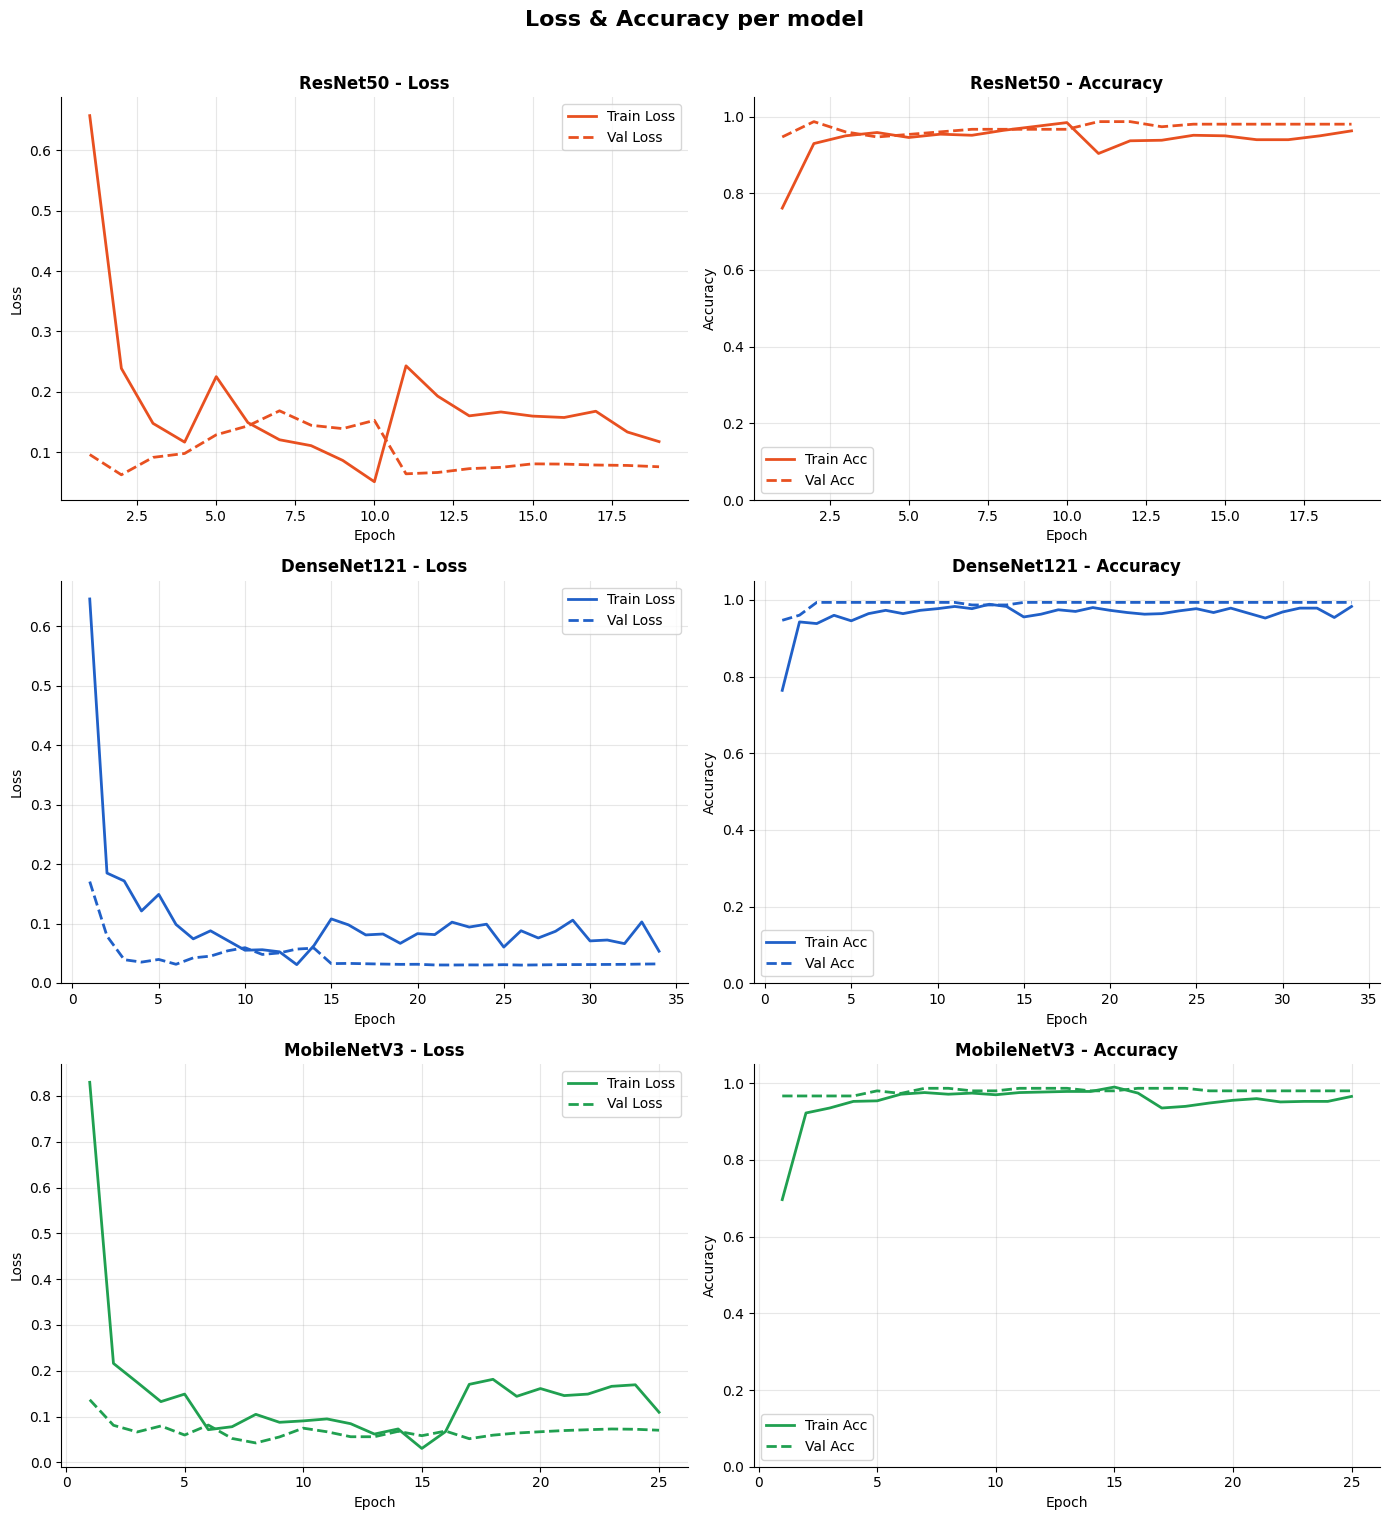

Plot saved: /content/drive/MyDrive/AnimalClassification/loss_accuracy_curves.png
Found 155 files belonging to 5 classes.
Found 155 files belonging to 5 classes.
Found 155 files belonging to 5 classes.


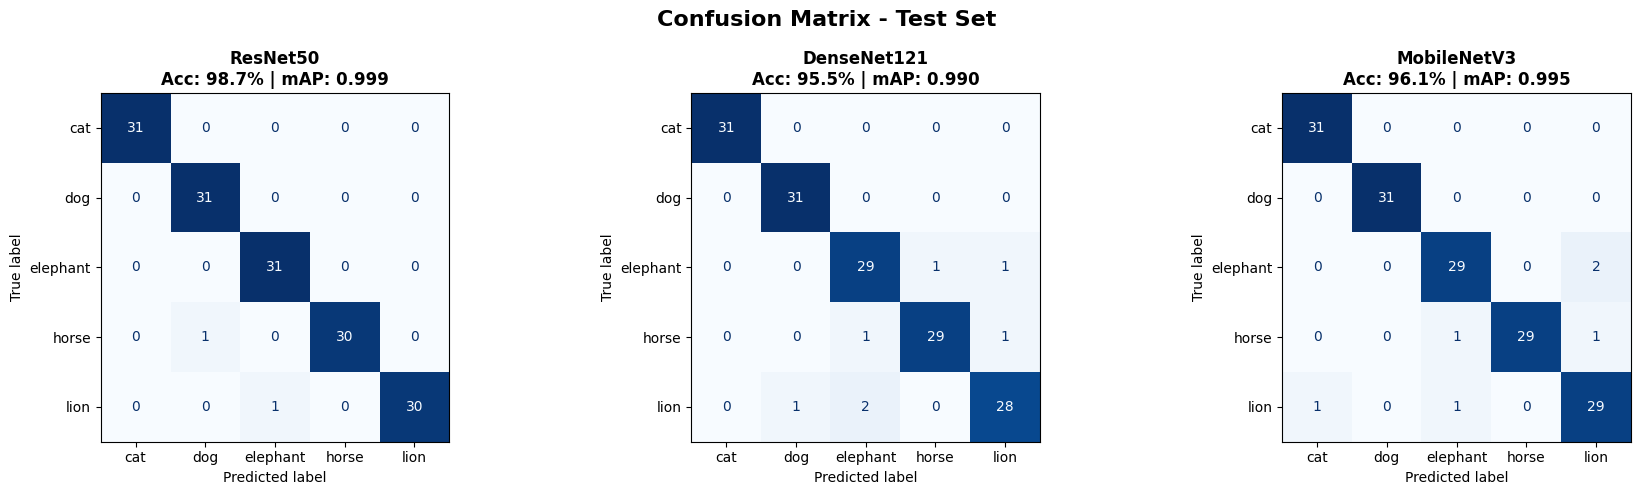

Plot saved: /content/drive/MyDrive/AnimalClassification/confusion_matrices.png


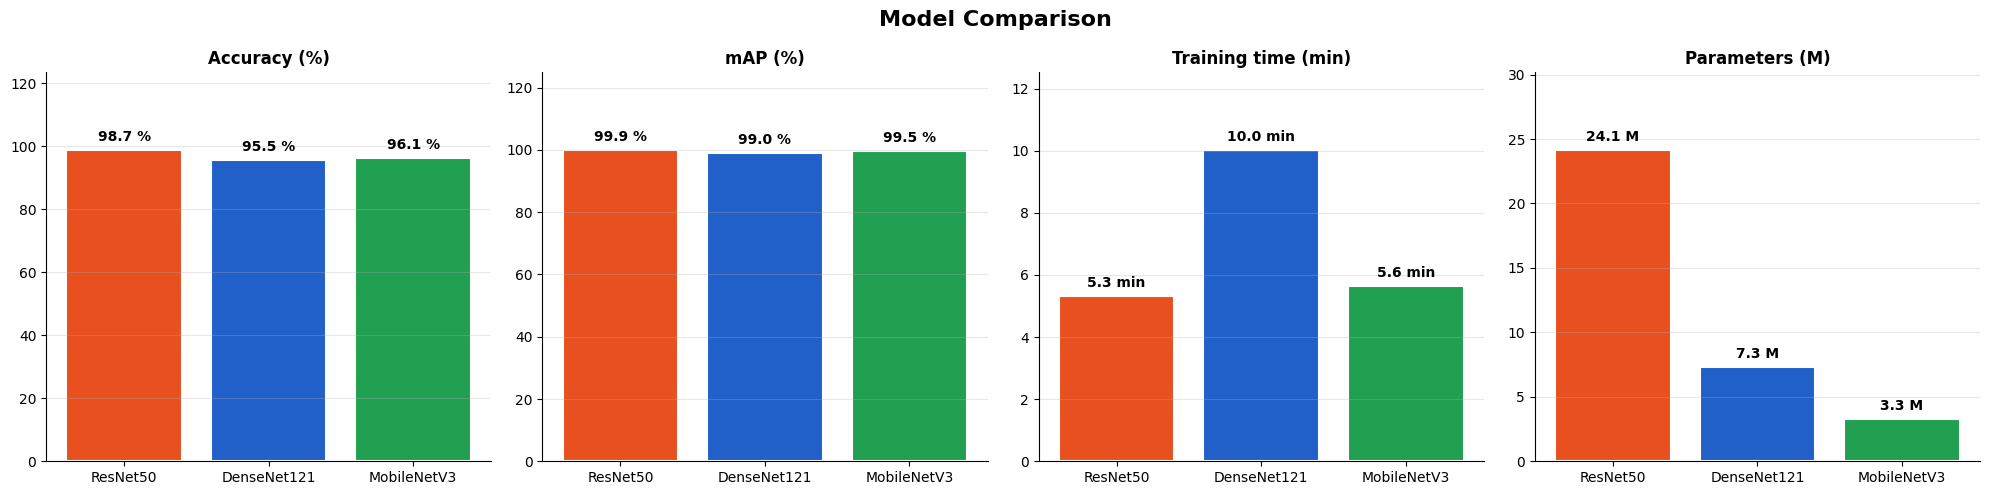

Plot saved: /content/drive/MyDrive/AnimalClassification/model_comparison.png

  CONCLUSION
  Best Accuracy    : ResNet50 (98.71%)
  Best mAP         : ResNet50 (0.9994)
  Fastest training : ResNet50 (5.3 min)

All plots are ready for presentation!


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_pre
from tensorflow.keras.applications.densenet     import preprocess_input as densenet_pre
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenet_pre

# Check: results must exist
if 'results' not in vars() or not results:
    raise RuntimeError(
        "The variable 'results' is empty.\n"
        "Please run Cell 4 first."
    )

# Paths
PROJECT_DIR = '/content/drive/MyDrive/AnimalClassification'
DATASET_DIR = os.path.join(PROJECT_DIR, 'dataset')
MODELS_DIR  = os.path.join(PROJECT_DIR, 'saved_models')

train_dir = os.path.join(DATASET_DIR, 'train')
CLASSES   = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

PALETTE = {'ResNet50': '#E85020', 'DenseNet121': '#2060C8', 'MobileNetV3': '#20A050'}
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16

# 1. Loss & Accuracy curves
fig, axes = plt.subplots(len(results), 2, figsize=(14, 5 * len(results)))
if len(results) == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('Loss & Accuracy per model', fontsize=16, fontweight='bold', y=1.01)

for i, (name, r) in enumerate(results.items()):
    hist   = r['history']
    color  = PALETTE.get(name, '#555555')
    epochs = range(1, len(hist['loss']) + 1)

    axes[i, 0].plot(epochs, hist['loss'],     color=color, lw=2, label='Train Loss')
    axes[i, 0].plot(epochs, hist['val_loss'], color=color, lw=2, ls='--', label='Val Loss')
    axes[i, 0].set_title(f'{name} - Loss', fontweight='bold')
    axes[i, 0].set_xlabel('Epoch'); axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].spines[['top', 'right']].set_visible(False)

    axes[i, 1].plot(epochs, hist['accuracy'],     color=color, lw=2, label='Train Acc')
    axes[i, 1].plot(epochs, hist['val_accuracy'], color=color, lw=2, ls='--', label='Val Acc')
    axes[i, 1].set_title(f'{name} - Accuracy', fontweight='bold')
    axes[i, 1].set_xlabel('Epoch'); axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].set_ylim(0, 1.05)
    axes[i, 1].legend(); axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = os.path.join(PROJECT_DIR, 'loss_accuracy_curves.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {out}')

# 2. Confusion matrices
PRE_FNS = {'ResNet50': resnet_pre, 'DenseNet121': densenet_pre, 'MobileNetV3': mobilenet_pre}

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]
fig.suptitle('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    model_path = os.path.join(MODELS_DIR, f'{name}.keras')
    if not os.path.exists(model_path):
        ax.set_title(f'{name}\n(model not found)')
        continue

    model  = tf.keras.models.load_model(model_path)
    pre_fn = PRE_FNS[name]

    test_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, 'test'),
        labels='inferred', label_mode='int',
        class_names=CLASSES, image_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False,
    ).map(lambda x, y: (pre_fn(tf.cast(x, tf.float32)), y)).prefetch(tf.data.AUTOTUNE)

    y_true, y_pred = [], []
    for imgs, labels in test_ds:
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(model.predict(imgs, verbose=0), axis=1))

    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_title(f'{name}\nAcc: {r["test_accuracy"]*100:.1f}% | mAP: {r["mAP"]:.3f}', fontweight='bold')

plt.tight_layout()
out = os.path.join(PROJECT_DIR, 'confusion_matrices.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {out}')

# 3. Global comparison
names  = list(results.keys())
accs   = [r['test_accuracy'] * 100  for r in results.values()]
maps   = [r['mAP'] * 100            for r in results.values()]
times  = [r['training_time'] / 60   for r in results.values()]
params = [r['num_params'] / 1e6     for r in results.values()]
colors = [PALETTE.get(n, '#888') for n in names]

metrics_info = [
    (accs,   'Accuracy (%)',             '%'),
    (maps,   'mAP (%)',                  '%'),
    (times,  'Training time (min)',      'min'),
    (params, 'Parameters (M)',           'M'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

for ax, (vals, title, unit) in zip(axes, metrics_info):
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25 if max(vals) > 0 else 1)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f'{v:.1f} {unit}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
out = os.path.join(PROJECT_DIR, 'model_comparison.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {out}')

# Conclusion
best_acc = max(results, key=lambda m: results[m]['test_accuracy'])
best_map = max(results, key=lambda m: results[m]['mAP'])
fastest  = min(results, key=lambda m: results[m]['training_time'])

print('\n' + '='*60)
print('  CONCLUSION')
print('='*60)
print(f'  Best Accuracy    : {best_acc} ({results[best_acc]["test_accuracy"]*100:.2f}%)')
print(f'  Best mAP         : {best_map} ({results[best_map]["mAP"]:.4f})')
print(f'  Fastest training : {fastest} ({results[fastest]["training_time"]/60:.1f} min)')
print('='*60)
print('\nAll plots are ready for presentation!')